# 2021 Census of Population, Census Profile

The census profile presents information from the 2021 Census of Population for various levels of geography, including provinces and territories, census metropolitan areas, communities and census tracts.

This is the continuation of the second notebook. On this notebook all the Dot Density Maps will be performed.

## Reading the CSV file

First, import the dataframe that was previosly created and contains the information of interest.

In [1]:
# import libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
#from geopandas.GeoSeries import sample_points

In [2]:
print(gpd.__version__)

1.0.1


In [3]:
# show all columns
pd.set_option('display.max_columns', None)

In [4]:
# import csv file
df12_c1 = pd.read_csv("df12_c1.csv")

In [5]:
df12_c1 = df12_c1.rename(columns= {
    '  Americas':'Americas',
    '  Europe':'Europe',
    '  Africa':'Africa',
    '  Asia':'Asia',
    '  Oceania and other places of birth':'Oceania and other places of birth'
} )

In [6]:
df12_c1.head()

,DGUID,Americas,Europe,Africa,Asia,Oceania and other places of birth
0,2021S05075350001.00,30.0,50.0,0.0,65.0,0.0
1,2021S05075350002.00,25.0,95.0,0.0,0.0,0.0
2,2021S05075350003.00,35.0,45.0,10.0,125.0,0.0
3,2021S05075350004.00,420.0,560.0,150.0,1465.0,10.0
4,2021S05075350005.00,455.0,645.0,320.0,1090.0,0.0


In [7]:
# import shp file
gdf = gpd.read_file(f"zip://{"lct_000b21a_e.zip"}")

In [8]:
gdf = gdf.drop(columns=["CTUID","CTNAME","PRUID", "LANDAREA"]).copy()

In [9]:
gdf.head()

,DGUID,geometry
0,2021S05075370001.08,"POLYGON ((7196507.366 869787.991, 7196501.617 ..."
1,2021S05070010002.00,"POLYGON ((8980216.643 2151065.36, 8980377.609 ..."
2,2021S05075370001.09,"POLYGON ((7196437.003 869160.246, 7196434.403 ..."
3,2021S05075370120.02,"POLYGON ((7189475.703 865662.849, 7189448.943 ..."
4,2021S05070010006.00,"POLYGON ((8980091.143 2152478.609, 8980100.254..."


In [10]:
# adding geometry: left join DGUID
gdf12_c1 = df12_c1.merge(gdf, on='DGUID')

In [11]:
gdf12_c1.head()

,DGUID,Americas,Europe,Africa,Asia,Oceania and other places of birth,geometry
0,2021S05075350001.00,30.0,50.0,0.0,65.0,0.0,"MULTIPOLYGON (((7228907.129 925600.146, 722890..."
1,2021S05075350002.00,25.0,95.0,0.0,0.0,0.0,"MULTIPOLYGON (((7225485.523 924880.603, 722548..."
2,2021S05075350003.00,35.0,45.0,10.0,125.0,0.0,"MULTIPOLYGON (((7220414.503 925572.426, 722041..."
3,2021S05075350004.00,420.0,560.0,150.0,1465.0,10.0,"POLYGON ((7220890.583 926060.209, 7220963.994 ..."
4,2021S05075350005.00,455.0,645.0,320.0,1090.0,0.0,"POLYGON ((7221811.977 926672.983, 7221851.546 ..."


### Dot Density Map

In [12]:
# recalculate values as 1 per 100 persons, rounded to nearest 100.
factor = 100

gdf12_c1[['Americas', 'Europe', 'Africa', 'Asia', 'Oceania and other places of birth']] = \
    round(gdf12_c1[['Americas', 'Europe', 'Africa', 'Asia', 'Oceania and other places of birth']] / factor).astype('int')

In [13]:
gdf12_c1.head()

,DGUID,Americas,Europe,Africa,Asia,Oceania and other places of birth,geometry
0,2021S05075350001.00,0,0,0,1,0,"MULTIPOLYGON (((7228907.129 925600.146, 722890..."
1,2021S05075350002.00,0,1,0,0,0,"MULTIPOLYGON (((7225485.523 924880.603, 722548..."
2,2021S05075350003.00,0,0,0,1,0,"MULTIPOLYGON (((7220414.503 925572.426, 722041..."
3,2021S05075350004.00,4,6,2,15,0,"POLYGON ((7220890.583 926060.209, 7220963.994 ..."
4,2021S05075350005.00,5,6,3,11,0,"POLYGON ((7221811.977 926672.983, 7221851.546 ..."


In [14]:
type(gdf12_c1) # it is a dataframe not a geodataframe

pandas.core.frame.DataFrame

### function: random n points within polygons based on multiple columns

In [40]:
# define polygons
r = gdf12_c1
r

,DGUID,Americas,Europe,Africa,Asia,Oceania and other places of birth,geometry
0,2021S05075350001.00,0,0,0,1,0,"MULTIPOLYGON (((7228907.129 925600.146, 722890..."
1,2021S05075350002.00,0,1,0,0,0,"MULTIPOLYGON (((7225485.523 924880.603, 722548..."
2,2021S05075350003.00,0,0,0,1,0,"MULTIPOLYGON (((7220414.503 925572.426, 722041..."
3,2021S05075350004.00,4,6,2,15,0,"POLYGON ((7220890.583 926060.209, 7220963.994 ..."
4,2021S05075350005.00,5,6,3,11,0,"POLYGON ((7221811.977 926672.983, 7221851.546 ..."
...,...,...,...,...,...,...,...
1222,2021S05075350820.07,4,3,1,7,0,"POLYGON ((7246472.68 957026.703, 7246679.254 9..."
1223,2021S05075350830.00,1,5,0,3,0,"POLYGON ((7235947.083 979154.917, 7235967.383 ..."
1224,2021S05075350831.01,1,4,0,1,0,"POLYGON ((7234037.026 982851.663, 7233931.083 ..."
1225,2021S05075350831.02,1,6,0,2,0,"POLYGON ((7239701.549 981189.34, 7239631.623 9..."


In [41]:
# make a GeoDataFrame
r = gpd.GeoDataFrame(r, geometry='geometry')
r

,DGUID,Americas,Europe,Africa,Asia,Oceania and other places of birth,geometry
0,2021S05075350001.00,0,0,0,1,0,"MULTIPOLYGON (((7228907.129 925600.146, 722890..."
1,2021S05075350002.00,0,1,0,0,0,"MULTIPOLYGON (((7225485.523 924880.603, 722548..."
2,2021S05075350003.00,0,0,0,1,0,"MULTIPOLYGON (((7220414.503 925572.426, 722041..."
3,2021S05075350004.00,4,6,2,15,0,"POLYGON ((7220890.583 926060.209, 7220963.994 ..."
4,2021S05075350005.00,5,6,3,11,0,"POLYGON ((7221811.977 926672.983, 7221851.546 ..."
...,...,...,...,...,...,...,...
1222,2021S05075350820.07,4,3,1,7,0,"POLYGON ((7246472.68 957026.703, 7246679.254 9..."
1223,2021S05075350830.00,1,5,0,3,0,"POLYGON ((7235947.083 979154.917, 7235967.383 ..."
1224,2021S05075350831.01,1,4,0,1,0,"POLYGON ((7234037.026 982851.663, 7233931.083 ..."
1225,2021S05075350831.02,1,6,0,2,0,"POLYGON ((7239701.549 981189.34, 7239631.623 9..."


In [44]:
r.iloc[:,1:6]

,Americas,Europe,Africa,Asia,Oceania and other places of birth
0,0,0,0,1,0
1,0,1,0,0,0
2,0,0,0,1,0
3,4,6,2,15,0
4,5,6,3,11,0
...,...,...,...,...,...
1222,4,3,1,7,0
1223,1,5,0,3,0
1224,1,4,0,1,0
1225,1,6,0,2,0


In [45]:
# function with preserve sampling size column name
def random_pts(gdf, start_col_index, end_col_index):

    col_list = list(range(start_col_index,end_col_index)) # define list with required range
    all_points = [] # define empty list
    
    for n in col_list:

        # sampling points within geom
        multipoints = gdf.sample_points(size=gdf.iloc[:,n])
        
        # making a GeoDataFrame
        mp_gdf = gpd.GeoDataFrame(
            geometry = multipoints,
            crs=gdf.crs
        )
    
        mp_gdf['source'] = gdf.columns[n]
    
        # make a dataframe with each random point
        points_gdf = mp_gdf.explode(index_parts=False).reset_index(drop=True)

        # add to the list
        all_points.append(points_gdf)

    # concatenate all points 
    result = pd.concat(all_points, ignore_index=True)

    return result

In [46]:
points_gdf = random_pts(r,1,6)
points_gdf

,source,geometry
0,Americas,POINT (7220080.277 926033.442)
1,Americas,POINT (7220343.774 925999.109)
2,Americas,POINT (7220390.994 925943.826)
3,Americas,POINT (7220565.526 926177.538)
4,Americas,POINT (7220751.977 926354.486)
...,...,...
28526,Asia,POINT (7241132.819 975411.439)
28527,Asia,POINT (7233600.131 985876.098)
28528,Asia,POINT (7234489.895 982216.297)
28529,Asia,POINT (7237457.588 983380.067)


In [56]:
points_gdf.crs

<Projected CRS: EPSG:3347>
Name: NAD83 / Statistics Canada Lambert
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Canada - onshore and offshore - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon.
- bounds: (-141.01, 38.21, -40.73, 86.46)
Coordinate Operation:
- name: Statistics Canada Lambert
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [55]:
# Write the results to file.
points_gdf.to_csv('out.csv', index=False)

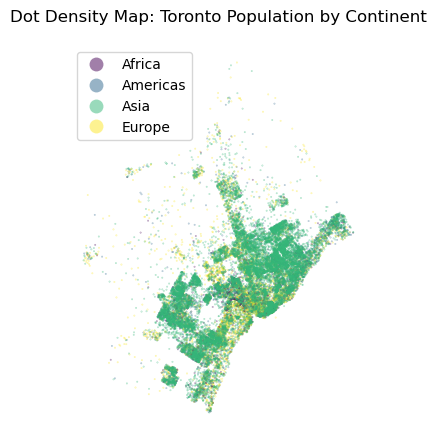

In [53]:
import matplotlib.pyplot as plt
# basic plot
points_gdf.plot(
    figsize=(5,5), column='source', cmap='viridis', legend=True,
    markersize=.1, alpha=.5
)

plt.title("Dot Density Map: Toronto Population by Continent")
plt.axis('off')

plt.show()

# Resouces

- [Census Profile, 2021 Census of Population](https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/index.cfm?Lang=E)
- [About the Census Profile, 2021 Census of Population](https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/about-apropos/about-apropos.cfm?Lang=E#aa1)
- [Guide to the Census of Population, 2021](https://www12.statcan.gc.ca/census-recensement/2021/ref/98-304/index-eng.cfm),  provides an overview of the Census of Population content determination, collection, processing, data quality assessment and data dissemination. It may be useful to both new and experienced users who wish to familiarize themselves with and find specific information about the 2021 Census
- [Filling the gaps: Information on gender in the 2021 Census](https://www12.statcan.gc.ca/census-recensement/2021/ref/98-20-0001/982000012021001-eng.cfm), defines gender, sex at birth, and relevant concepts as the Census 2021 disseminates census information on gender
- [Census Profile metadata](https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/about-apropos/metadata-metadonnees-eng.cfm), list characteristics by topics and subtopic, and list all footnotes
- [Full Table Download (CSV) User Guide](https://www.statcan.gc.ca/en/developers/csv/user-guide), provides users with a guide to the full table downloadable output files available from the Statistics Canada website
- [Dictionary, Census of Population 2021, PDF version](https://www12.statcan.gc.ca/census-recensement/2021/ref/dict/98-301-x2021001-eng.pdf), is a reference document which contains detailed definitions of Census of Population concepts, variables and geographic terms, as well as historical information. The PDF version organizes the concepts by topics, which is not the case for the [web version](https://www12.statcan.gc.ca/census-recensement/2021/ref/dict/index-eng.cfm).
- [2021 Census – Boundary files](https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/boundary-limites/index2021-eng.cfm?year=21)
- [Boundary Files, Reference Guide, Census year 2021, Second Edition](https://www150.statcan.gc.ca/n1/en/catalogue/92-160-G2021002)

# Reference

Statistics Canada. 2023. Census Profile. 2021 Census of Population. Statistics Canada Catalogue number 98-316-X2021001. Ottawa. Released November 15, 2023.
*https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/index.cfm?Lang=E (accessed August 4, 2025).*